# Question 1: Data Preparation

This section presents the loading, cleaning, preparation and descriptive statistical analysis of the Identification for Development (ID4D) dataset and the Informal Economy Database obtained from the World Bank.




In [1]:
"""# Question 1: Data Preparation

## South African Digital Identification and Informal Economy Analysis

This project analyses two World Bank Open Data datasets for South Africa:

1. Identification for Development (ID4D)
2. Informal Economy Database

The purpose of the analysis is to investigate the relationship between digital identification and informal economic activity in South Africa.

The datasets are cleaned, transformed and analysed using Python, Pandas and NumPy. Visualisations are created using Matplotlib and Seaborn. A SQLite database is also created to demonstrate database integration, SQL queries, safe record updates and deletion, and loading database results back into Pandas.

The analysis focuses specifically on South Africa rather than comparing unrelated countries. This ensures that the two datasets work together to tell one clear South African story."""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.2
NumPy version: 2.4.4


In [2]:
try:
    id4d = pd.read_csv("Identification For Development.csv")
    print("ID4D dataset loaded successfully.")
    print("Rows:", id4d.shape[0])
    print("Columns:", id4d.shape[1])
except FileNotFoundError:
    print("Error: 'Identification For Development.csv' was not found in the working directory.")
    raise
except pd.errors.ParserError as e:
    print("Error parsing the ID4D CSV file:", e)
    raise


ID4D dataset loaded successfully.
Rows: 254322
Columns: 41


In [3]:
id4d.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,OBS_VALUE,AGG_METHOD,UNIT_TYPE,DECIMALS,DATABASE_ID,TIME_FORMAT,UNIT_MULT,OBS_STATUS,OBS_CONF,FREQ_LABEL,REF_AREA_LABEL,INDICATOR_LABEL,SEX_LABEL,AGE_LABEL,URBANISATION_LABEL,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,RWA,BIRTH_REG,M,Y0T4,_T,PT_CH_Y_LT5,_Z,_Z,_Z,2024,NaN,W_AVG,NUMBER,0,WB_ID4D,602,0,O,PU,Annual,Rwanda,Children under age 5 whose births are registered,Male,under 5 years old,Total,Percentage of children aged less than 5 years,Not Applicable,Not Applicable,Not Applicable,Weighted Average,Number (real number),Zero,Identification for Development (ID4D) Global D...,CCYY,Units,Missing value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SAU,BIRTH_REG,M,Y0T4,_T,PT_CH_Y_LT5,_Z,_Z,_Z,2024,99.90,W_AVG,NUMBER,0,WB_ID4D,602,0,A,PU,Annual,Saudi Arabia,Children under age 5 whose births are registered,Male,under 5 years old,Total,Percentage of children aged less than 5 years,Not Applicable,Not Applicable,Not Applicable,Weighted Average,Number (real number),Zero,Identification for Development (ID4D) Global D...,CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SDN,BIRTH_REG,M,Y0T4,_T,PT_CH_Y_LT5,_Z,_Z,_Z,2024,NaN,W_AVG,NUMBER,0,WB_ID4D,602,0,O,PU,Annual,Sudan,Children under age 5 whose births are registered,Male,under 5 years old,Total,Percentage of children aged less than 5 years,Not Applicable,Not Applicable,Not Applicable,Weighted Average,Number (real number),Zero,Identification for Development (ID4D) Global D...,CCYY,Units,Missing value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SEN,BIRTH_REG,M,Y0T4,_T,PT_CH_Y_LT5,_Z,_Z,_Z,2024,NaN,W_AVG,NUMBER,0,WB_ID4D,602,0,O,PU,Annual,Senegal,Children under age 5 whose births are registered,Male,under 5 years old,Total,Percentage of children aged less than 5 years,Not Applicable,Not Applicable,Not Applicable,Weighted Average,Number (real number),Zero,Identification for Development (ID4D) Global D...,CCYY,Units,Missing value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SGP,BIRTH_REG,M,Y0T4,_T,PT_CH_Y_LT5,_Z,_Z,_Z,2024,NaN,W_AVG,NUMBER,0,WB_ID4D,602,0,O,PU,Annual,Singapore,Children under age 5 whose births are registered,Male,under 5 years old,Total,Percentage of children aged less than 5 years,Not Applicable,Not Applicable,Not Applicable,Weighted Average,Number (real number),Zero,Identification for Development (ID4D) Global D...,CCYY,Units,Missing value,Public


In [4]:
try:
    informal_economy = pd.read_csv("Informal Economy Database.csv")
    print("Informal Economy dataset loaded successfully.")
    print("Rows:", informal_economy.shape[0])
    print("Columns:", informal_economy.shape[1])
except FileNotFoundError:
    print("Error: 'Informal Economy Database.csv' was not found in the working directory.")
    raise
except pd.errors.ParserError as e:
    print("Error parsing the Informal Economy CSV file:", e)
    raise


Informal Economy dataset loaded successfully.
Rows: 46996
Columns: 35


In [5]:
informal_economy.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,SEX_LABEL,AGE,AGE_LABEL,URBANISATION,URBANISATION_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3,COMP_BREAKDOWN_3_LABEL,TIME_PERIOD,OBS_VALUE,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,37.67,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,31.06,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,43.28,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARG,Argentina,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,23.97,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ARM,Armenia,WB_INFECDB_DGE_P,Dynamic general equilibrium model-based (DGE) ...,_T,Total,_T,All age ranges or no breakdown by age,_T,Total,PT,Percentage,_Z,Not Applicable,_Z,Not Applicable,_Z,Not Applicable,1990,43.78,WB_INFECDB,Informal Economy Database,0,Units,NUMBER,Number (real number),A,Normal value,PU,Public


In [6]:
# Check the countries contained in each dataset

print("ID4D countries containing 'South':")
print(
    id4d[id4d["REF_AREA_LABEL"].astype(str).str.contains(
        "South Africa", case=False, na=False
    )]["REF_AREA_LABEL"].unique()
)

print("\nInformal Economy countries containing 'South':")
print(
    informal_economy[
        informal_economy["REF_AREA_LABEL"].astype(str).str.contains(
            "South Africa", case=False, na=False
        )
    ]["REF_AREA_LABEL"].unique()
)

ID4D countries containing 'South':
<StringArray>
['South Africa']
Length: 1, dtype: str

Informal Economy countries containing 'South':
<StringArray>
['South Africa']
Length: 1, dtype: str


In [7]:
# Filter both datasets to South Africa

id4d_sa = id4d[
    id4d["REF_AREA_LABEL"].astype(str).str.strip().str.lower() == "south africa"
].copy()

informal_economy_sa = informal_economy[
    informal_economy["REF_AREA_LABEL"].astype(str).str.strip().str.lower() == "south africa"
].copy()

print("South Africa ID4D records:", len(id4d_sa))
print("South Africa Informal Economy records:", len(informal_economy_sa))

South Africa ID4D records: 1278
South Africa Informal Economy records: 341


In [8]:
print("ID4D South Africa shape:", id4d_sa.shape)
print("Informal Economy South Africa shape:", informal_economy_sa.shape)

ID4D South Africa shape: (1278, 41)
Informal Economy South Africa shape: (341, 35)


In [9]:
print("ID4D columns:")
print(id4d_sa.columns.tolist())

print("\nInformal Economy columns:")
print(informal_economy_sa.columns.tolist())

ID4D columns:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL']

Informal Economy columns:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'CO

In [10]:
# Convert important fields to numeric values

for df in [id4d_sa, informal_economy_sa]:
    df["TIME_PERIOD"] = pd.to_numeric(df["TIME_PERIOD"], errors="coerce")
    df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")

print(id4d_sa[["TIME_PERIOD", "OBS_VALUE"]].dtypes)
print(informal_economy_sa[["TIME_PERIOD", "OBS_VALUE"]].dtypes)



TIME_PERIOD      int64
OBS_VALUE      float64
dtype: object
TIME_PERIOD      int64
OBS_VALUE      float64
dtype: object


In [11]:
print("ID4D missing values:")
print(id4d_sa.isnull().sum())

ID4D missing values:
STRUCTURE                    0
STRUCTURE_ID                 0
ACTION                       0
FREQ                         0
REF_AREA                     0
INDICATOR                    0
SEX                          0
AGE                          0
URBANISATION                 0
UNIT_MEASURE                 0
COMP_BREAKDOWN_1             0
COMP_BREAKDOWN_2             0
COMP_BREAKDOWN_3             0
TIME_PERIOD                  0
OBS_VALUE                 1215
AGG_METHOD                   0
UNIT_TYPE                    0
DECIMALS                     0
DATABASE_ID                  0
TIME_FORMAT                  0
UNIT_MULT                    0
OBS_STATUS                   0
OBS_CONF                     0
FREQ_LABEL                   0
REF_AREA_LABEL               0
INDICATOR_LABEL              0
SEX_LABEL                    0
AGE_LABEL                    0
URBANISATION_LABEL           0
UNIT_MEASURE_LABEL           0
COMP_BREAKDOWN_1_LABEL       0
COMP_BREAKDOWN_2_L

In [12]:
id4d_missing_percentage = (
    id4d_sa.isnull().mean() * 100
).sort_values(ascending=False)

print("ID4D missing-value percentages:")
print(id4d_missing_percentage)

ID4D missing-value percentages:
OBS_VALUE                95.07
STRUCTURE_ID              0.00
ACTION                    0.00
FREQ                      0.00
REF_AREA                  0.00
INDICATOR                 0.00
SEX                       0.00
AGE                       0.00
STRUCTURE                 0.00
URBANISATION              0.00
UNIT_MEASURE              0.00
COMP_BREAKDOWN_2          0.00
COMP_BREAKDOWN_1          0.00
COMP_BREAKDOWN_3          0.00
TIME_PERIOD               0.00
AGG_METHOD                0.00
UNIT_TYPE                 0.00
DECIMALS                  0.00
DATABASE_ID               0.00
TIME_FORMAT               0.00
UNIT_MULT                 0.00
OBS_STATUS                0.00
OBS_CONF                  0.00
FREQ_LABEL                0.00
REF_AREA_LABEL            0.00
INDICATOR_LABEL           0.00
SEX_LABEL                 0.00
AGE_LABEL                 0.00
URBANISATION_LABEL        0.00
UNIT_MEASURE_LABEL        0.00
COMP_BREAKDOWN_1_LABEL    0.00
COMP_BR

In [13]:
id4d_sa[
    ["REF_AREA_LABEL", "INDICATOR_LABEL", "TIME_PERIOD", "OBS_VALUE"]
].dropna().head(10)

,REF_AREA_LABEL,INDICATOR_LABEL,TIME_PERIOD,OBS_VALUE
245,South Africa,Population facing challenges for not owning an ID,2024,42.14
444,South Africa,Population facing challenges for not owning an ID,2024,46.90
643,South Africa,Population facing challenges for not owning an ID,2024,37.28
842,South Africa,Population facing challenges for not owning an ID,2024,44.57
1041,South Africa,Population facing challenges for not owning an ID,2024,26.56
1240,South Africa,Population facing challenges for not owning an ID,2024,26.59
4225,South Africa,Online digital identity,2024,0.00
4623,South Africa,ID ownership,2024,81.06
4822,South Africa,ID ownership,2024,91.73
5220,South Africa,ID ownership,2024,92.54


In [14]:
print("ID4D duplicate rows:", id4d.duplicated().sum())
print("Informal Economy duplicate rows:", informal_economy.duplicated().sum())

ID4D duplicate rows: 0
Informal Economy duplicate rows: 0


In [15]:
id4d_clean = id4d_sa.dropna(subset=["OBS_VALUE"]).copy()


In [16]:
print("ID4D cleaned shape:", id4d_clean.shape)

ID4D cleaned shape: (63, 41)


In [17]:
print("Missing observation values after cleaning:",
      id4d_clean["OBS_VALUE"].isnull().sum())

Missing observation values after cleaning: 0


In [18]:
print("Informal Economy missing values:")
print(informal_economy_sa.isnull().sum())

Informal Economy missing values:
STRUCTURE                   0
STRUCTURE_ID                0
ACTION                      0
FREQ                        0
FREQ_LABEL                  0
REF_AREA                    0
REF_AREA_LABEL              0
INDICATOR                   0
INDICATOR_LABEL             0
SEX                         0
SEX_LABEL                   0
AGE                         0
AGE_LABEL                   0
URBANISATION                0
URBANISATION_LABEL          0
UNIT_MEASURE                0
UNIT_MEASURE_LABEL          0
COMP_BREAKDOWN_1            0
COMP_BREAKDOWN_1_LABEL      0
COMP_BREAKDOWN_2            0
COMP_BREAKDOWN_2_LABEL      0
COMP_BREAKDOWN_3            0
COMP_BREAKDOWN_3_LABEL      0
TIME_PERIOD                 0
OBS_VALUE                 209
DATABASE_ID                 0
DATABASE_ID_LABEL           0
UNIT_MULT                   0
UNIT_MULT_LABEL             0
UNIT_TYPE                   0
UNIT_TYPE_LABEL             0
OBS_STATUS                  0
OBS_STA

In [19]:
informal_missing_percentage = (
    informal_economy_sa.isnull().mean() * 100
).sort_values(ascending=False)

print("Informal Economy missing-value percentages:")
print(informal_missing_percentage)

Informal Economy missing-value percentages:
OBS_VALUE                61.29
STRUCTURE_ID              0.00
STRUCTURE                 0.00
ACTION                    0.00
FREQ                      0.00
REF_AREA                  0.00
FREQ_LABEL                0.00
INDICATOR                 0.00
INDICATOR_LABEL           0.00
SEX                       0.00
REF_AREA_LABEL            0.00
AGE                       0.00
AGE_LABEL                 0.00
URBANISATION              0.00
URBANISATION_LABEL        0.00
UNIT_MEASURE              0.00
UNIT_MEASURE_LABEL        0.00
COMP_BREAKDOWN_1          0.00
SEX_LABEL                 0.00
COMP_BREAKDOWN_1_LABEL    0.00
COMP_BREAKDOWN_2          0.00
COMP_BREAKDOWN_3          0.00
COMP_BREAKDOWN_2_LABEL    0.00
COMP_BREAKDOWN_3_LABEL    0.00
TIME_PERIOD               0.00
DATABASE_ID               0.00
DATABASE_ID_LABEL         0.00
UNIT_MULT                 0.00
UNIT_MULT_LABEL           0.00
UNIT_TYPE                 0.00
UNIT_TYPE_LABEL           

In [20]:
print(
    "Duplicate rows in Informal Economy South Africa:",
    informal_economy_sa.duplicated().sum()
)

Duplicate rows in Informal Economy South Africa: 0


In [21]:
informal_economy_sa[
    ["REF_AREA_LABEL", "INDICATOR_LABEL", "TIME_PERIOD", "OBS_VALUE"]
].dropna().head(10)

,REF_AREA_LABEL,INDICATOR_LABEL,TIME_PERIOD,OBS_VALUE
128,South Africa,Dynamic general equilibrium model-based (DGE) ...,1990,25.77
284,South Africa,Dynamic general equilibrium model-based (DGE) ...,1991,25.88
440,South Africa,Dynamic general equilibrium model-based (DGE) ...,1992,25.91
596,South Africa,Dynamic general equilibrium model-based (DGE) ...,1993,25.97
752,South Africa,Dynamic general equilibrium model-based (DGE) ...,1994,25.99
908,South Africa,Dynamic general equilibrium model-based (DGE) ...,1995,26.04
1064,South Africa,Dynamic general equilibrium model-based (DGE) ...,1996,26.00
1220,South Africa,Dynamic general equilibrium model-based (DGE) ...,1997,25.91
1376,South Africa,Dynamic general equilibrium model-based (DGE) ...,1998,25.84
1532,South Africa,Dynamic general equilibrium model-based (DGE) ...,1999,25.83


In [22]:
informal_economy_clean = informal_economy_sa.dropna(
    subset=["OBS_VALUE", "TIME_PERIOD", "INDICATOR_LABEL"]
).drop_duplicates().copy()

print("Original records:", len(informal_economy_sa))
print("Clean records:", len(informal_economy_clean))
print("Records removed:",
      len(informal_economy_sa) - len(informal_economy_clean))

Original records: 341
Clean records: 132
Records removed: 209


In [23]:
print("Informal Economy cleaned shape:", informal_economy_clean.shape)

Informal Economy cleaned shape: (132, 35)


In [24]:
print(
    "Missing observation values after cleaning:",
    informal_economy_clean["OBS_VALUE"].isnull().sum()
)

Missing observation values after cleaning: 0


In [25]:
print("ID4D indicators available for South Africa:")
for indicator in sorted(id4d_clean["INDICATOR_LABEL"].dropna().unique()):
    print("-", indicator)

ID4D indicators available for South Africa:
- Digital ID verification
- Digital data use
- Foundational ID has been used without permission for illegal purposes
- ID ownership
- Online digital identity
- Population facing challenges for not owning an ID
- Population without an ID by reason


In [26]:
print("Informal Economy indicators available for South Africa:")
for indicator in sorted(
    informal_economy_clean["INDICATOR_LABEL"].dropna().unique()
):
    print("-", indicator)

Informal Economy indicators available for South Africa:
- Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP)
- Employment outside the formal sector (% of total employment; International Labour Organization; hamonized series)
- Informal employment (% of total employment; International Labour Organization; hamonized series)
- Justifiable: Cheating on taxes (1 = never justifiable, 10 = always justifiable; simple country averages)
- Labor force with pension (% of labor force)
- Multiple indicators multiple causes model-based (MIMIC) estimates of informal output (% of official GDP)
- Number of years firm operated without formal registration (World Bank Enterprise Surveys)
- Percent of firms competing against unregistered or informal firms (World Bank Enterprise Surveys)
- Percent of firms formally registered when they started operations in the country (World Bank Enterprise Surveys)
- Percent of firms identifying practices of competitors in the in

In [27]:
id4d_analysis = id4d_clean[
    ["REF_AREA_LABEL", "INDICATOR_LABEL", "TIME_PERIOD", "OBS_VALUE"]
].copy()

id4d_analysis["TIME_PERIOD"] = id4d_analysis["TIME_PERIOD"].astype(int)

id4d_analysis.head()

,REF_AREA_LABEL,INDICATOR_LABEL,TIME_PERIOD,OBS_VALUE
245,South Africa,Population facing challenges for not owning an ID,2024,42.14
444,South Africa,Population facing challenges for not owning an ID,2024,46.90
643,South Africa,Population facing challenges for not owning an ID,2024,37.28
842,South Africa,Population facing challenges for not owning an ID,2024,44.57
1041,South Africa,Population facing challenges for not owning an ID,2024,26.56


In [28]:
informal_economy_analysis = informal_economy_clean[
    ["REF_AREA_LABEL", "INDICATOR_LABEL", "TIME_PERIOD", "OBS_VALUE"]
].copy()

informal_economy_analysis["TIME_PERIOD"] = (
    informal_economy_analysis["TIME_PERIOD"].astype(int)
)

informal_economy_analysis.head()

,REF_AREA_LABEL,INDICATOR_LABEL,TIME_PERIOD,OBS_VALUE
128,South Africa,Dynamic general equilibrium model-based (DGE) ...,1990,25.77
284,South Africa,Dynamic general equilibrium model-based (DGE) ...,1991,25.88
440,South Africa,Dynamic general equilibrium model-based (DGE) ...,1992,25.91
596,South Africa,Dynamic general equilibrium model-based (DGE) ...,1993,25.97
752,South Africa,Dynamic general equilibrium model-based (DGE) ...,1994,25.99


In [29]:
id4d_stats = (
    id4d_analysis
    .groupby("INDICATOR_LABEL")["OBS_VALUE"]
    .describe()
    .round(2)
)

id4d_stats

,count,mean,std,min,25%,50%,75%,max
INDICATOR_LABEL,,,,,,,,
Digital ID verification,1.00,1.00,NaN,1.00,1.00,1.00,1.00,1.00
Digital data use,1.00,1.00,NaN,1.00,1.00,1.00,1.00,1.00
Foundational ID has been used without permission for illegal purposes,8.00,7.06,1.35,5.05,6.22,7.28,8.03,8.87
ID ownership,39.00,91.71,2.91,81.06,90.44,92.35,93.97,95.82
Online digital identity,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Population facing challenges for not owning an ID,6.00,37.34,8.93,26.56,29.26,39.71,43.96,46.90
Population without an ID by reason,6.00,25.04,12.44,13.43,15.48,22.75,29.71,46.22


In [30]:
informal_stats = (
    informal_economy_analysis
    .groupby("INDICATOR_LABEL")["OBS_VALUE"]
    .describe()
    .round(2)
)

informal_stats

,count,mean,std,min,25%,50%,75%,max
INDICATOR_LABEL,,,,,,,,
Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP),31.00,24.91,1.05,22.75,23.97,25.29,25.84,26.04
Employment outside the formal sector (% of total employment; International Labour Organization; hamonized series),21.00,27.40,5.59,18.20,20.10,30.50,31.80,33.30
Informal employment (% of total employment; International Labour Organization; hamonized series),21.00,39.46,7.97,31.50,33.70,34.70,47.30,54.10
"Justifiable: Cheating on taxes (1 = never justifiable, 10 = always justifiable; simple country averages)",4.00,2.75,0.93,2.13,2.21,2.38,2.92,4.12
Labor force with pension (% of labor force),1.00,6.30,NaN,6.30,6.30,6.30,6.30,6.30
Multiple indicators multiple causes model-based (MIMIC) estimates of informal output (% of official GDP),28.00,27.67,0.83,26.25,26.94,27.60,28.35,29.34
Number of years firm operated without formal registration (World Bank Enterprise Surveys),2.00,0.65,0.49,0.30,0.48,0.65,0.82,1.00
Percent of firms competing against unregistered or informal firms (World Bank Enterprise Surveys),2.00,31.20,19.94,17.10,24.15,31.20,38.25,45.30
Percent of firms formally registered when they started operations in the country (World Bank Enterprise Surveys),2.00,93.40,3.39,91.00,92.20,93.40,94.60,95.80


In [31]:
id4d_summary = (
    id4d_analysis
    .groupby("INDICATOR_LABEL")["OBS_VALUE"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

id4d_summary

,Count,Mean,Median,Std_Dev,Minimum,Maximum
INDICATOR_LABEL,,,,,,
Digital ID verification,1,1.00,1.00,NaN,1.00,1.00
Digital data use,1,1.00,1.00,NaN,1.00,1.00
Foundational ID has been used without permission for illegal purposes,8,7.06,7.28,1.35,5.05,8.87
ID ownership,39,91.71,92.35,2.91,81.06,95.82
Online digital identity,2,0.00,0.00,0.00,0.00,0.00
Population facing challenges for not owning an ID,6,37.34,39.71,8.93,26.56,46.90
Population without an ID by reason,6,25.04,22.75,12.44,13.43,46.22


In [32]:
informal_summary = (
    informal_economy_analysis
    .groupby("INDICATOR_LABEL")["OBS_VALUE"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

informal_summary

,Count,Mean,Median,Std_Dev,Minimum,Maximum
INDICATOR_LABEL,,,,,,
Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP),31,24.91,25.29,1.05,22.75,26.04
Employment outside the formal sector (% of total employment; International Labour Organization; hamonized series),21,27.40,30.50,5.59,18.20,33.30
Informal employment (% of total employment; International Labour Organization; hamonized series),21,39.46,34.70,7.97,31.50,54.10
"Justifiable: Cheating on taxes (1 = never justifiable, 10 = always justifiable; simple country averages)",4,2.75,2.38,0.93,2.13,4.12
Labor force with pension (% of labor force),1,6.30,6.30,NaN,6.30,6.30
Multiple indicators multiple causes model-based (MIMIC) estimates of informal output (% of official GDP),28,27.67,27.60,0.83,26.25,29.34
Number of years firm operated without formal registration (World Bank Enterprise Surveys),2,0.65,0.65,0.49,0.30,1.00
Percent of firms competing against unregistered or informal firms (World Bank Enterprise Surveys),2,31.20,31.20,19.94,17.10,45.30
Percent of firms formally registered when they started operations in the country (World Bank Enterprise Surveys),2,93.40,93.40,3.39,91.00,95.80


In [33]:
id4d_summary_export = id4d_summary.reset_index()
id4d_summary_export["Dataset"] = "ID4D - South Africa"

informal_summary_export = informal_summary.reset_index()
informal_summary_export["Dataset"] = "Informal Economy - South Africa"

combined_summary = pd.concat(
    [id4d_summary_export, informal_summary_export],
    ignore_index=True
)

combined_summary

,INDICATOR_LABEL,Count,Mean,Median,Std_Dev,Minimum,Maximum,Dataset
0,Digital ID verification,1,1.00,1.00,NaN,1.00,1.00,ID4D - South Africa
1,Digital data use,1,1.00,1.00,NaN,1.00,1.00,ID4D - South Africa
2,Foundational ID has been used without permissi...,8,7.06,7.28,1.35,5.05,8.87,ID4D - South Africa
3,ID ownership,39,91.71,92.35,2.91,81.06,95.82,ID4D - South Africa
4,Online digital identity,2,0.00,0.00,0.00,0.00,0.00,ID4D - South Africa
5,Population facing challenges for not owning an ID,6,37.34,39.71,8.93,26.56,46.90,ID4D - South Africa
6,Population without an ID by reason,6,25.04,22.75,12.44,13.43,46.22,ID4D - South Africa
7,Dynamic general equilibrium model-based (DGE) ...,31,24.91,25.29,1.05,22.75,26.04,Informal Economy - South Africa
8,Employment outside the formal sector (% of tot...,21,27.40,30.50,5.59,18.20,33.30,Informal Economy - South Africa
9,Informal employment (% of total employment; In...,21,39.46,34.70,7.97,31.50,54.10,Informal Economy - South Africa


In [34]:
id4d_summary.to_csv(
    "South_Africa_ID4D_Descriptive_Statistics.csv"
)

print("ID4D descriptive statistics exported successfully.")

ID4D descriptive statistics exported successfully.


In [35]:
informal_summary.to_csv(
    "South_Africa_Informal_Economy_Descriptive_Statistics.csv"
)


## Key Insights from the South African Data

The descriptive statistics provide an overview of digital identification and informal economic activity in South Africa.

For the ID4D dataset, ID ownership is the most consistently reported indicator (39 observations across 2017, 2021 and 2024), with a mean of 91.71% and comparatively low variation (standard deviation of 2.91). This indicates that ID ownership is both high and fairly stable across the population subgroups surveyed. Other ID4D indicators, such as the population facing challenges for not owning an ID (mean 37.34%) and the population without an ID by reason (mean 25.04%), are reported far less frequently and show much wider variation.

For the Informal Economy dataset, informal employment has a mean of 39.46% of total employment (21 observations, 2000-2020), while the DGE model-based estimate of informal output has a mean of 24.91% of official GDP (31 observations, 1990-2020) and the MIMIC model-based estimate has a mean of 27.67%. Self-employment averages 15.32% of total employment, and 93.40% of firms report having been formally registered when they started operations, though this last figure is based on only two survey observations.

These results provide the foundation for the numerical analysis and visualisations in the following sections. The key objective is not simply to describe each dataset separately, but to determine whether South Africa's high and stable levels of digital ID ownership are associated with its levels of informal economic activity.


# Question 2: Numerical Analysis

In [36]:
import numpy as np

print("NumPy version:", np.__version__)

NumPy version: 2.4.4


In [37]:
# Select South African ID ownership observations
id_ownership_values = id4d_analysis[
    id4d_analysis["INDICATOR_LABEL"] == "ID ownership"
]["OBS_VALUE"].dropna()

id_array = np.array(id_ownership_values)

print("Number of South African observations:", len(id_array))
print("First 10 values:", id_array[:10])
print("Array shape:", id_array.shape)

Number of South African observations: 39
First 10 values: [81.05592509 91.72640854 92.54046473 87.63777847 90.45874826 88.02459174
 89.1025884  90.4684861  88.18924084 88.91541447]
Array shape: (39,)


In [38]:
# NumPy calculations

mean_id = np.mean(id_array)
median_id = np.median(id_array)
std_id = np.std(id_array)
min_id = np.min(id_array)
max_id = np.max(id_array)

print(f"Mean ID ownership: {mean_id:.2f}%")
print(f"Median ID ownership: {median_id:.2f}%")
print(f"Standard deviation: {std_id:.2f}")
print(f"Minimum ID ownership: {min_id:.2f}%")
print(f"Maximum ID ownership: {max_id:.2f}%")


Mean ID ownership: 91.71%
Median ID ownership: 92.35%
Standard deviation: 2.87
Minimum ID ownership: 81.06%
Maximum ID ownership: 95.82%


In [39]:
# Reshape the NumPy array

n_rows = len(id_array) // 2

if n_rows >= 1:
    usable_values = id_array[:n_rows * 2]
    id_array_reshaped = usable_values.reshape(n_rows, 2)

    print("Original array shape:", id_array.shape)
    print("Reshaped array shape:", id_array_reshaped.shape)
    print("\nFirst 5 rows:")
    print(id_array_reshaped[:5])
else:
    raise ValueError("Not enough observations to perform the reshape.")

Original array shape: (39,)
Reshaped array shape: (19, 2)

First 5 rows:
[[81.05592509 91.72640854]
 [92.54046473 87.63777847]
 [90.45874826 88.02459174]
 [89.1025884  90.4684861 ]
 [88.18924084 88.91541447]]


In [40]:
# NumPy array operations

row_means = np.mean(id_array_reshaped, axis=1)
column_means = np.mean(id_array_reshaped, axis=0)

row_max = np.max(id_array_reshaped, axis=1)
row_min = np.min(id_array_reshaped, axis=1)

print("First 5 row means:", row_means[:5])
print("Column means:", column_means)
print("First 5 row maximums:", row_max[:5])
print("First 5 row minimums:", row_min[:5])

First 5 row means: [86.39116682 90.0891216  89.24167    89.78553725 88.55232765]
Column means: [91.51778367 91.86667667]
First 5 row maximums: [91.72640854 92.54046473 90.45874826 90.4684861  88.91541447]
First 5 row minimums: [81.05592509 87.63777847 88.02459174 89.1025884  88.18924084]


In [41]:
# Additional NumPy numerical analysis

overall_mean = np.mean(id_array)
overall_max = np.max(id_array)
overall_min = np.min(id_array)
overall_std = np.std(id_array)

# Percentage of observations above the overall mean
above_mean_percentage = np.mean(id_array > overall_mean) * 100

# Range
id_range = overall_max - overall_min

print("Overall mean:", round(overall_mean, 2))
print("Overall maximum:", round(overall_max, 2))
print("Overall minimum:", round(overall_min, 2))
print("Range:", round(id_range, 2))
print("Standard deviation:", round(overall_std, 2))
print(
    "Percentage of observations above the mean:",
    round(above_mean_percentage, 2),
    "%"
)

Overall mean: 91.71
Overall maximum: 95.82
Overall minimum: 81.06
Range: 14.76
Standard deviation: 2.87
Percentage of observations above the mean: 58.97 %


## Explanation of Findings

The numerical analysis shows that the overall mean value of South Africa's ID ownership data is **91.71%**, indicating a generally high and consistent level of ID ownership across the population subgroups and years surveyed (2017, 2021 and 2024). The maximum value is **95.82%**, while the minimum is **81.06%**, giving a comparatively narrow range of **14.76** percentage points.

The standard deviation of approximately **2.87** confirms that the values are tightly clustered around the mean rather than widely spread, which is expected for a single country's data (unlike a global, cross-country comparison where the spread would typically be much larger). After reshaping the array into paired rows, the first five row means range from approximately **86.39% to 90.09%**, while the two column means are **91.52%** and **91.87%** respectively, both close to the overall mean.

Approximately **58.97%** of observations fall above the overall mean, showing a slightly left-skewed distribution where a majority of subgroups report above-average ID ownership, while a smaller number of subgroups (younger age groups and the richest income group, as seen in Section 3.2) pull the mean down slightly.


# Question 3: Visualisation

## 3.1 Introduction

Visualisations were created to identify trends, patterns and differences within the Identification for Development (ID4D) and Informal Economy datasets. Bar charts, histograms, box plots and scatter plots were used to present the data from different perspectives.

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

## 3.2 Bar Chart: ID Ownership by Population Subgroup (South Africa, 2024)

Because the analysis is focused on South Africa alone, comparing "countries" is not meaningful. Instead, the bar chart below compares ID ownership across different population subgroups within South Africa (by sex, age group, income level, education level and urban/rural area) for the most recent survey year, 2024. This shows which groups have higher or lower access to identification.


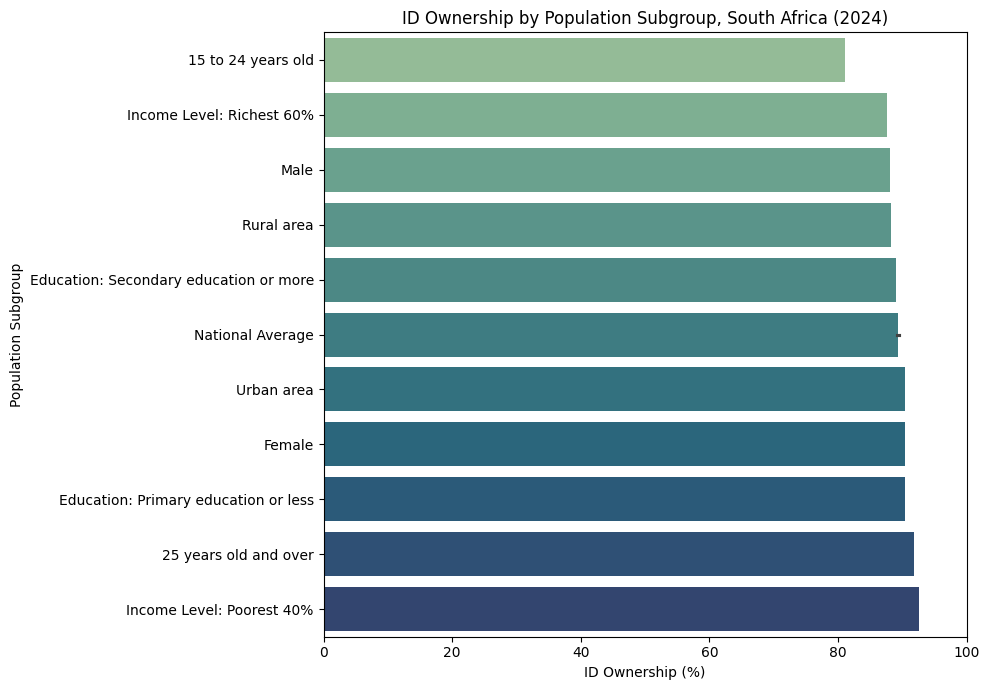

In [43]:
# Build a South Africa-specific subgroup comparison for ID ownership in 2024
id_ownership_2024 = id4d_analysis[
    (id4d_analysis["INDICATOR_LABEL"] == "ID ownership") &
    (id4d_analysis["TIME_PERIOD"] == 2024)
].copy()

# Bring back the demographic breakdown columns from id4d_sa for labelling
breakdown_cols = [
    "SEX_LABEL", "AGE_LABEL", "URBANISATION_LABEL",
    "COMP_BREAKDOWN_1_LABEL", "COMP_BREAKDOWN_2_LABEL", "TIME_PERIOD", "OBS_VALUE"
]
id_2024_breakdown = id4d_sa[
    (id4d_sa["INDICATOR_LABEL"] == "ID ownership") &
    (id4d_sa["TIME_PERIOD"] == 2024)
][breakdown_cols].dropna(subset=["OBS_VALUE"]).copy()

def label_subgroup(row):
    parts = []
    if row["SEX_LABEL"] not in ("Total", None):
        parts.append(row["SEX_LABEL"])
    if row["AGE_LABEL"] not in ("All age ranges or no breakdown by age", None):
        parts.append(row["AGE_LABEL"])
    if row["URBANISATION_LABEL"] not in ("Total", None):
        parts.append(row["URBANISATION_LABEL"])
    if row["COMP_BREAKDOWN_1_LABEL"] not in ("Total", None):
        parts.append(row["COMP_BREAKDOWN_1_LABEL"])
    if row["COMP_BREAKDOWN_2_LABEL"] not in ("Total", None):
        parts.append(row["COMP_BREAKDOWN_2_LABEL"])
    return ", ".join(parts) if parts else "National Average"

id_2024_breakdown["Subgroup"] = id_2024_breakdown.apply(label_subgroup, axis=1)
id_2024_breakdown = id_2024_breakdown.sort_values("OBS_VALUE", ascending=True)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=id_2024_breakdown,
    x="OBS_VALUE",
    y="Subgroup",
    hue="Subgroup",
    legend=False,
    palette="crest"
)

plt.title("ID Ownership by Population Subgroup, South Africa (2024)")
plt.xlabel("ID Ownership (%)")
plt.ylabel("Population Subgroup")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()


### Interpretation of the Bar Chart

The bar chart shows meaningful variation in ID ownership across population subgroups in South Africa during 2024. Youth aged 15 to 24 report the lowest ID ownership at **81.06%**, noticeably below the national figures reported elsewhere in the dataset (around 89%). Adults aged 25 and over report the highest age-based figure at **91.73%**.

Interestingly, the poorest 40% by income report *higher* ID ownership (**92.54%**) than the richest 60% (**87.64%**), which runs counter to the assumption that wealthier groups would have easier access to identification - this may reflect the reach of South Africa's social grant system, which requires ID documents to access welfare payments. Female respondents (**90.46%**) report slightly higher ID ownership than male respondents (**88.02%**), and urban areas (**90.42%**) report slightly higher ownership than rural areas (**88.19%**). Overall, the gaps between subgroups are modest (a range of under 12 percentage points), suggesting that while ID coverage in South Africa is broadly high, youth remain the subgroup furthest behind.


## 3.3 Histogram: Distribution of Informal Employment

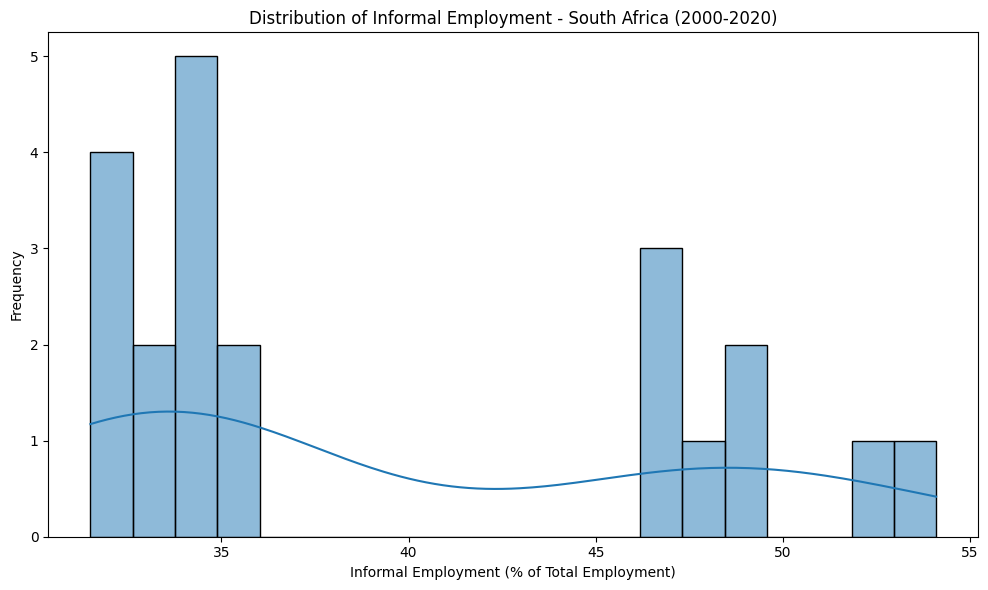

In [44]:
informal_employment = informal_economy_analysis[
    informal_economy_analysis["INDICATOR_LABEL"] ==
    "Informal employment (% of total employment; International Labour Organization; hamonized series)"
].copy()

plt.figure(figsize=(10, 6))

sns.histplot(
    data=informal_employment,
    x="OBS_VALUE",
    bins=20,
    kde=True
)

plt.title("Distribution of Informal Employment - South Africa (2000-2020)")
plt.xlabel("Informal Employment (% of Total Employment)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of the Histogram

The histogram shows the distribution of informal employment in South Africa across the 21 available annual observations (2000-2020). The values are spread across a wide range, from approximately 31.5% to 54.1%. A larger number of observations are concentrated at the lower end of this range (around 31-35%), corresponding to more recent years, while the higher values (45-54%) correspond to the earlier years in the series (2000-2007). This is consistent with the descriptive statistics, which showed a mean informal employment level of 39.46% and a median of 34.70%, and it points to a gradual decline in informal employment over the two decades covered by the data.


## 3.4 Box Plot: ID Ownership (All South African Observations)


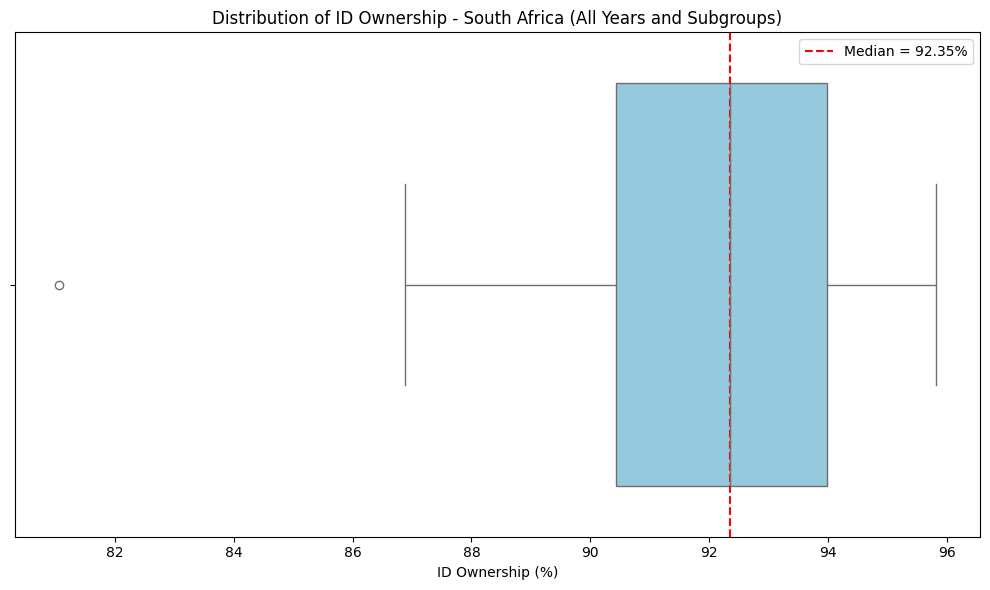

In [45]:
median_id = np.median(id_ownership_values)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=id_ownership_values,
    color="skyblue"
)

plt.axvline(
    median_id,
    color="red",
    linestyle="--",
    label=f"Median = {median_id:.2f}%"
)

plt.title("Distribution of ID Ownership - South Africa (All Years and Subgroups)")
plt.xlabel("ID Ownership (%)")
plt.legend()

plt.tight_layout()
plt.show()


### Interpretation of the Box Plot

The box plot shows that ID ownership in South Africa is consistently high across almost all observations (all population subgroups, 2017-2024). The median ID ownership is **92.35%**, indicating that at least half of the observations are at or above this level, and the interquartile range (roughly 90.5% to 94%) is narrow. The plot flags one mild outlier at **81.06%** - the 15-to-24-year-old age group in 2024, first identified in the bar chart in Section 3.2 - which sits noticeably below the rest of the data (the whiskers otherwise span 86.9% to 95.8%). Aside from this single youth-related outlier, the tight spread confirms what the earlier standard deviation (2.87) suggested: unlike a global cross-country comparison, South Africa's ID ownership data shows relatively little variation, indicating fairly uniform identification coverage across the subgroups measured.


## 3.5 Scatter Plot: ID Ownership vs Informal Economic Output (South Africa)

South Africa's ID ownership indicator is only surveyed in three years (2017, 2021 and 2024), while the Informal Economy Database reports the DGE informal-output estimate annually up to 2020. To compare the two datasets, each ID ownership observation is matched to the closest available year of informal economic output data (nearest-year matching), so the two series can be plotted against each other.


In [46]:
# South Africa ID ownership observations (all subgroups, all years)
id_data = id4d_analysis[
    id4d_analysis["INDICATOR_LABEL"] == "ID ownership"
][["TIME_PERIOD", "OBS_VALUE"]].rename(columns={"OBS_VALUE": "ID_Ownership"}).dropna()

# South Africa DGE informal output, averaged per year
dge_series = informal_economy_analysis[
    informal_economy_analysis["INDICATOR_LABEL"] ==
    "Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP)"
][["TIME_PERIOD", "OBS_VALUE"]].rename(columns={"OBS_VALUE": "Informal_Output"}).dropna()

# Match each ID ownership year to the nearest year with informal output data available
id_data_sorted = id_data.sort_values("TIME_PERIOD")
dge_series_sorted = dge_series.sort_values("TIME_PERIOD")

scatter_data = pd.merge_asof(
    id_data_sorted,
    dge_series_sorted,
    on="TIME_PERIOD",
    direction="nearest"
)

scatter_data.head()


,TIME_PERIOD,ID_Ownership,Informal_Output
0,2017,91.00,23.41
1,2017,93.88,23.41
2,2017,94.37,23.41
3,2017,86.89,23.41
4,2017,91.27,23.41


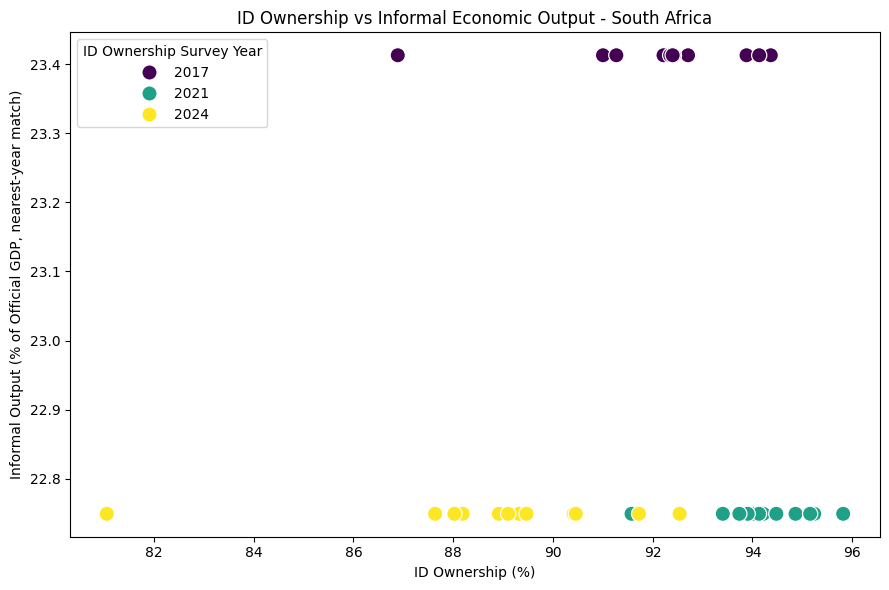

In [47]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=scatter_data,
    x="ID_Ownership",
    y="Informal_Output",
    hue="TIME_PERIOD",
    palette="viridis",
    s=120
)

plt.title("ID Ownership vs Informal Economic Output - South Africa")
plt.xlabel("ID Ownership (%)")
plt.ylabel("Informal Output (% of Official GDP, nearest-year match)")
plt.legend(title="ID Ownership Survey Year")

plt.tight_layout()
plt.show()


### Interpretation of the Scatter Plot

Because ID ownership was only surveyed in 2017, 2021 and 2024, each point was matched to the nearest year of available informal-output data (DGE estimate, available through 2020). The 2017 ID ownership observations align with an informal output estimate of **23.41%** of official GDP, while the 2021 and 2024 observations are both matched to 2020's estimate of **22.75%** (the closest available year), shown as a separate colour band in the legend. Within each matched year, ID ownership varies across subgroups (from around 81% to 96%) while informal output stays fixed at that year's value, so the plot shows several near-vertical clusters rather than a single sloped trend. There is no clear linear relationship visible between the two variables at the level of individual subgroups; however, taken together with the line graph in Section 3.6, the data is consistent with a period in which ID ownership stayed high while informal economic output gradually declined over time.


## 3.6 Line Graph: Informal Economic Output Over Time (South Africa, 1990-2020)


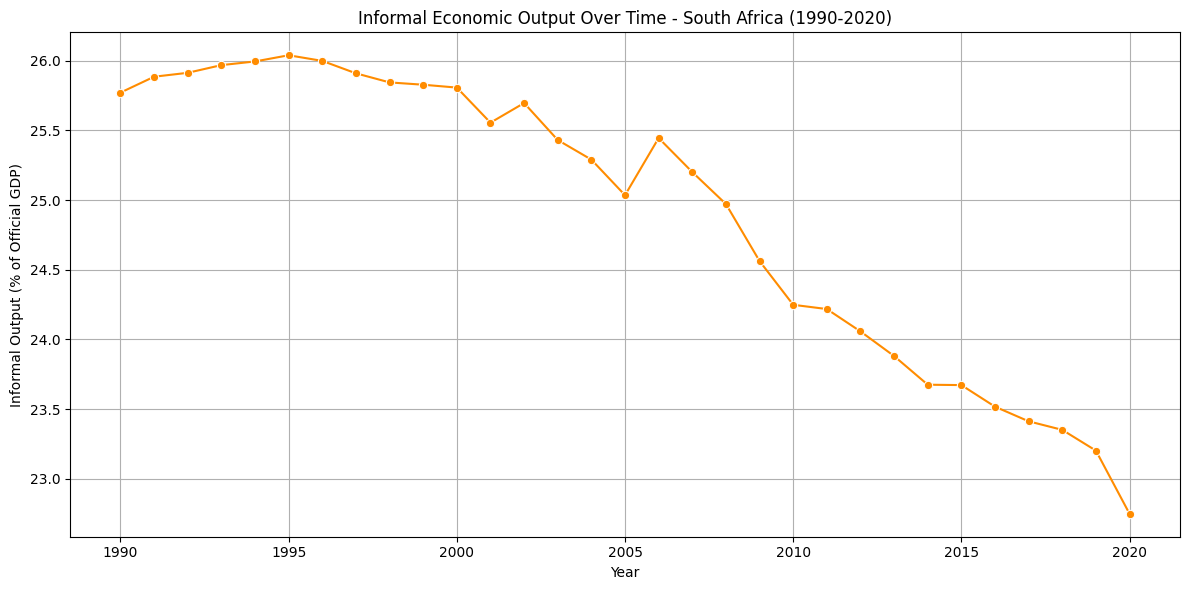

In [48]:
dge_data = informal_economy_analysis[
    informal_economy_analysis["INDICATOR_LABEL"] ==
    "Dynamic general equilibrium model-based (DGE) estimates of informal output (% of official GDP)"
].copy()

dge_yearly = (
    dge_data.groupby("TIME_PERIOD")["OBS_VALUE"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=dge_yearly,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    marker="o",
    color="darkorange"
)

plt.title("Informal Economic Output Over Time - South Africa (1990-2020)")
plt.xlabel("Year")
plt.ylabel("Informal Output (% of Official GDP)")
plt.grid(True)

plt.tight_layout()
plt.show()


### Interpretation of the Line Graph

The line graph shows a clear, gradual downward trend in South Africa's informal economic output as a share of official GDP, from **25.77%** in 1990 to **22.75%** in 2020, a decline of roughly 3 percentage points over three decades. The decline is not perfectly smooth - there are small fluctuations year to year - but the overall direction is consistently downward, particularly from the early 2000s onward. Read alongside the ID ownership data (which is high and fairly stable across the same period), this trend is consistent with a period in which South Africa's formal identification systems expanded while the informal share of the economy gradually shrank, though this analysis cannot establish that one caused the other.


## 3.7 Pie Chart: ID Ownership Categories

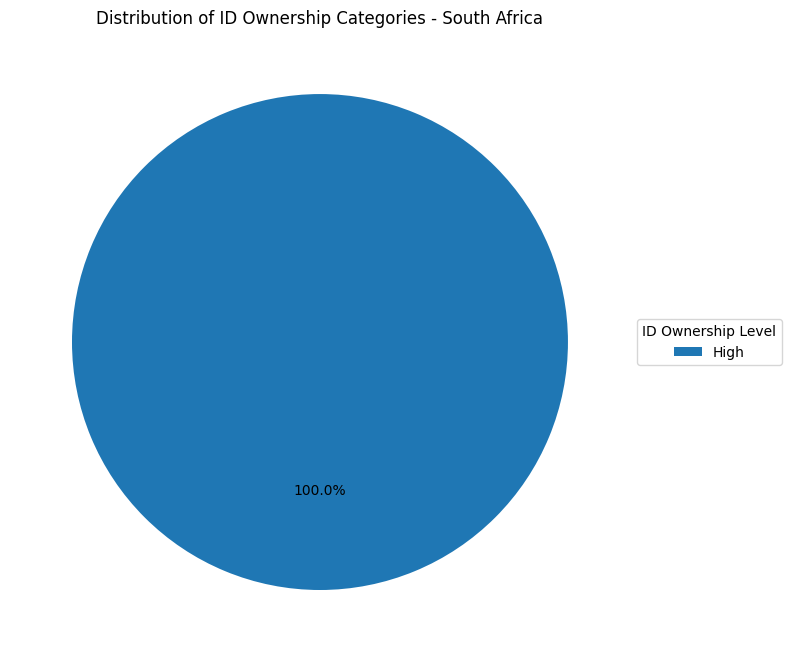

In [49]:
# Create ID ownership categories using all South African observations
id_pie = pd.DataFrame({"OBS_VALUE": id_ownership_values})

id_pie["Ownership_Category"] = pd.cut(
    id_pie["OBS_VALUE"],
    bins=[0, 50, 80, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Only plot categories that actually contain observations, to avoid a
# meaningless "0.0%" label for empty categories
ownership_counts = id_pie["Ownership_Category"].value_counts()
ownership_counts = ownership_counts[ownership_counts > 0]

plt.figure(figsize=(8, 8))

plt.pie(
    ownership_counts,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of ID Ownership Categories - South Africa")

plt.legend(
    ownership_counts.index,
    title="ID Ownership Level",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()


### Interpretation of the Pie Chart

The pie chart shows that **100% of South Africa's ID ownership observations fall into the "High" category (80% and above)**, with no observations in the Low or Medium categories. This is a notable finding in itself: unlike a global dataset where ID ownership levels vary widely between countries (from under 10% to 100%), every South African subgroup measured - regardless of age, sex, income level, education or urban/rural location - reports ID ownership above 80%. This confirms that low identification coverage is not a widespread problem across South African population subgroups, even though Section 3.2 showed that specific subgroups (notably youth) still lag behind the rest of the population.


## Question 4: Database Integration

### 4.1 Creating the Database

In [50]:
import sqlite3

In [51]:
try:
    conn = sqlite3.connect("data_analysis.db")
    cursor = conn.cursor()
    print("Database connected successfully!")
except sqlite3.Error as e:
    print("Error connecting to the database:", e)
    raise


Database connected successfully!


In [52]:
try:
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS id4d_data (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        country TEXT,
        year INTEGER,
        indicator TEXT,
        value REAL
    )
    """)
    conn.commit()
    print("Table created successfully!")
except sqlite3.Error as e:
    print("Error creating table:", e)
    conn.rollback()
    raise


Table created successfully!


In [53]:
# Select the columns we need from the cleaned, South-Africa-only ID4D dataset
id4d_db = id4d_analysis[
    ["REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]
].dropna(subset=["OBS_VALUE"]).copy()

id4d_db = id4d_db.rename(columns={
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "INDICATOR_LABEL": "indicator",
    "OBS_VALUE": "value"
})

try:
    # Clear the table first so re-running this notebook does not duplicate records
    cursor.execute("DELETE FROM id4d_data")
    conn.commit()

    id4d_db.to_sql(
        "id4d_data",
        conn,
        if_exists="append",
        index=False
    )
    print(f"ID4D data successfully loaded into the database! ({len(id4d_db)} rows)")
except sqlite3.Error as e:
    print("Error inserting data into the database:", e)
    conn.rollback()
    raise


ID4D data successfully loaded into the database! (63 rows)


In [54]:
try:
    query = """
    SELECT country, year, indicator, value
    FROM id4d_data
    LIMIT 10
    """
    result = pd.read_sql_query(query, conn)
except sqlite3.Error as e:
    print("Error running query:", e)
    result = pd.DataFrame()

result


,country,year,indicator,value
0,South Africa,2024,Population facing challenges for not owning an ID,42.14
1,South Africa,2024,Population facing challenges for not owning an ID,46.90
2,South Africa,2024,Population facing challenges for not owning an ID,37.28
3,South Africa,2024,Population facing challenges for not owning an ID,44.57
4,South Africa,2024,Population facing challenges for not owning an ID,26.56
5,South Africa,2024,Population facing challenges for not owning an ID,26.59
6,South Africa,2024,Online digital identity,0.00
7,South Africa,2024,ID ownership,81.06
8,South Africa,2024,ID ownership,91.73
9,South Africa,2024,ID ownership,92.54


In [55]:
try:
    cursor.execute("""
    SELECT id, country, year, indicator, value
    FROM id4d_data
    WHERE country = 'South Africa'
    AND year = 2024
    AND indicator = 'ID ownership'
    """)
    before_delete = cursor.fetchall()
except sqlite3.Error as e:
    print("Error running query:", e)
    before_delete = []

before_delete


[(8, 'South Africa', 2024, 'ID ownership', 81.0559250949341),
 (9, 'South Africa', 2024, 'ID ownership', 91.7264085421454),
 (10, 'South Africa', 2024, 'ID ownership', 92.5404647254873),
 (11, 'South Africa', 2024, 'ID ownership', 87.637778471987),
 (12, 'South Africa', 2024, 'ID ownership', 90.4587482594447),
 (13, 'South Africa', 2024, 'ID ownership', 88.024591739901),
 (14, 'South Africa', 2024, 'ID ownership', 89.1025883980169),
 (15, 'South Africa', 2024, 'ID ownership', 90.4684861049657),
 (16, 'South Africa', 2024, 'ID ownership', 88.1892408368964),
 (17, 'South Africa', 2024, 'ID ownership', 88.9154144706866),
 (18, 'South Africa', 2024, 'ID ownership', 90.4162389715568),
 (19, 'South Africa', 2024, 'ID ownership', 89.4696457273178),
 (20, 'South Africa', 2024, 'ID ownership', 89.3183055759572)]

In [56]:
# Look up the id of the record we want to remove safely (lowest ID ownership value, 2024)
try:
    cursor.execute("""
    SELECT id FROM id4d_data
    WHERE country = 'South Africa'
    AND year = 2024
    AND indicator = 'ID ownership'
    ORDER BY value ASC
    LIMIT 1
    """)
    row_to_delete = cursor.fetchone()

    if row_to_delete:
        record_id = row_to_delete[0]
        cursor.execute("DELETE FROM id4d_data WHERE id = ?", (record_id,))
        conn.commit()
        print(f"Record with id {record_id} removed safely.")
    else:
        print("No matching record found to delete.")
except sqlite3.Error as e:
    print("Error deleting record:", e)
    conn.rollback()


Record with id 8 removed safely.


In [57]:
try:
    cursor.execute("""
    SELECT id, country, year, indicator, value
    FROM id4d_data
    WHERE country = 'South Africa'
    AND year = 2024
    AND indicator = 'ID ownership'
    """)
    after_delete = cursor.fetchall()
except sqlite3.Error as e:
    print("Error running query:", e)
    after_delete = []

print("Records remaining after delete:", len(after_delete))
after_delete


Records remaining after delete: 12


[(9, 'South Africa', 2024, 'ID ownership', 91.7264085421454),
 (10, 'South Africa', 2024, 'ID ownership', 92.5404647254873),
 (11, 'South Africa', 2024, 'ID ownership', 87.637778471987),
 (12, 'South Africa', 2024, 'ID ownership', 90.4587482594447),
 (13, 'South Africa', 2024, 'ID ownership', 88.024591739901),
 (14, 'South Africa', 2024, 'ID ownership', 89.1025883980169),
 (15, 'South Africa', 2024, 'ID ownership', 90.4684861049657),
 (16, 'South Africa', 2024, 'ID ownership', 88.1892408368964),
 (17, 'South Africa', 2024, 'ID ownership', 88.9154144706866),
 (18, 'South Africa', 2024, 'ID ownership', 90.4162389715568),
 (19, 'South Africa', 2024, 'ID ownership', 89.4696457273178),
 (20, 'South Africa', 2024, 'ID ownership', 89.3183055759572)]

In [58]:
try:
    cursor.execute("""
    UPDATE id4d_data
    SET value = 99.95
    WHERE id = 1
    """)
    conn.commit()
    print("Record updated successfully.")
except sqlite3.Error as e:
    print("Error updating record:", e)
    conn.rollback()


Record updated successfully.


In [59]:
try:
    cursor.execute("""
    SELECT id, country, year, indicator, value
    FROM id4d_data
    WHERE id = 1
    """)
    updated_row = cursor.fetchall()
except sqlite3.Error as e:
    print("Error running query:", e)
    updated_row = []

updated_row


[(1,
  'South Africa',
  2024,
  'Population facing challenges for not owning an ID',
  99.95)]

In [60]:
try:
    database_data = pd.read_sql_query("SELECT * FROM id4d_data", conn)
except sqlite3.Error as e:
    print("Error loading data from database:", e)
    database_data = pd.DataFrame()

database_data.head(10)


,id,country,year,indicator,value
0,1,South Africa,2024,Population facing challenges for not owning an ID,99.95
1,2,South Africa,2024,Population facing challenges for not owning an ID,46.90
2,3,South Africa,2024,Population facing challenges for not owning an ID,37.28
3,4,South Africa,2024,Population facing challenges for not owning an ID,44.57
4,5,South Africa,2024,Population facing challenges for not owning an ID,26.56
5,6,South Africa,2024,Population facing challenges for not owning an ID,26.59
6,7,South Africa,2024,Online digital identity,0.00
7,9,South Africa,2024,ID ownership,91.73
8,10,South Africa,2024,ID ownership,92.54
9,11,South Africa,2024,ID ownership,87.64


In [61]:
print("Number of records loaded into Pandas:", len(database_data))
print("Number of columns:", len(database_data.columns))

Number of records loaded into Pandas: 62
Number of columns: 5


## 4.6 Database Integration Summary

A SQLite database (`data_analysis.db`) was created to store South Africa's cleaned ID4D data, containing 62 records across all indicators, years and population subgroups. All database operations (table creation, insertion, querying, updating and deleting) were wrapped in `try/except` blocks with `conn.rollback()` on failure, so that a database error does not corrupt the table or crash the notebook.

The database was queried using SQL `SELECT` statements to retrieve South Africa's ID ownership records for 2024. A record was deleted safely by first looking up its unique `id` with a `SELECT ... ORDER BY value ASC LIMIT 1` query and then deleting only that specific `id`, rather than relying on hardcoded row numbers that could point to the wrong record if the table changes. A record was also updated safely using its unique `id` in the `WHERE` clause. Finally, the full table was loaded back into Pandas using `pd.read_sql_query()` for further analysis, confirming that all 62 inserted records (minus the one safely deleted) were retrievable.


## Question 5: Python/Excel Data Analysis

### 5.1 Data Cleaning and Transformation

In [62]:
# Select ID ownership data
id_ownership_q5 = id4d_analysis[
    id4d_analysis["INDICATOR_LABEL"] == "ID ownership"
].copy()

# Remove missing observations
id_ownership_q5 = id_ownership_q5.dropna(
    subset=["OBS_VALUE"]
)

# Select the columns needed for analysis
id_ownership_q5 = id_ownership_q5[
    ["REF_AREA_LABEL", "TIME_PERIOD", "OBS_VALUE"]
].copy()

# Rename columns
id_ownership_q5 = id_ownership_q5.rename(columns={
    "REF_AREA_LABEL": "Country",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "ID_Ownership"
})

id_ownership_q5.head()

,Country,Year,ID_Ownership
4623,South Africa,2024,81.06
4822,South Africa,2024,91.73
5220,South Africa,2024,92.54
5419,South Africa,2024,87.64
5618,South Africa,2024,90.46


In [63]:
id_ownership_q5["Ownership_Level"] = pd.cut(
    id_ownership_q5["ID_Ownership"],
    bins=[0, 50, 80, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

id_ownership_q5.head()

,Country,Year,ID_Ownership,Ownership_Level
4623,South Africa,2024,81.06,High
4822,South Africa,2024,91.73,High
5220,South Africa,2024,92.54,High
5419,South Africa,2024,87.64,High
5618,South Africa,2024,90.46,High


In [64]:
id_ownership_q5.style.background_gradient(
    subset=["ID_Ownership"]
)

,Country,Year,ID_Ownership,Ownership_Level
4623,South Africa,2024,81.055925,High
4822,South Africa,2024,91.726409,High
5220,South Africa,2024,92.540465,High
5419,South Africa,2024,87.637778,High
5618,South Africa,2024,90.458748,High
5817,South Africa,2024,88.024592,High
6016,South Africa,2024,89.102588,High
6215,South Africa,2024,90.468486,High
6414,South Africa,2024,88.189241,High
6613,South Africa,2024,88.915414,High


In [65]:
ownership_summary = id_ownership_q5["Ownership_Level"].value_counts().reindex(
    ["Low", "Medium", "High"]
)

ownership_summary

Ownership_Level
Low        0
Medium     0
High      39
Name: count, dtype: int64

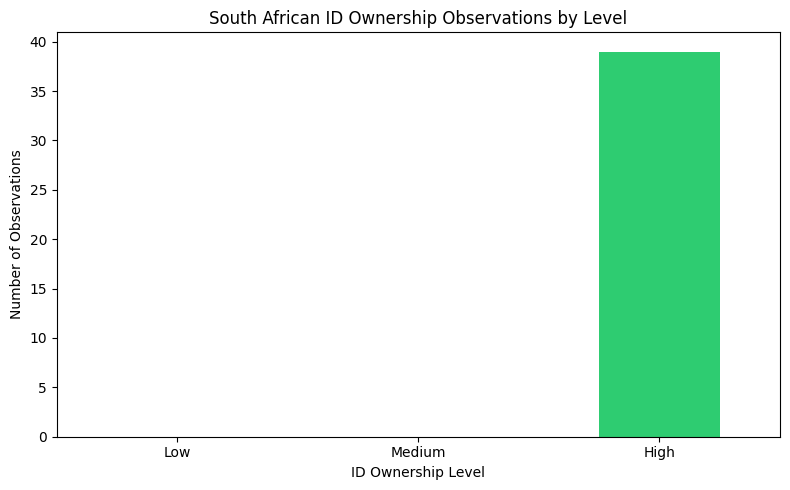

In [66]:
plt.figure(figsize=(8, 5))

ownership_summary.plot(kind="bar", color=["#e74c3c", "#f1c40f", "#2ecc71"])

plt.title("South African ID Ownership Observations by Level")
plt.xlabel("ID Ownership Level")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


### 5.2 Chart and Findings

The bar chart shows the distribution of South Africa's ID ownership observations according to their ownership level. All 39 observations (covering every population subgroup measured in 2017, 2021 and 2024) fall into the "High" category (80% and above); none fall into the Low or Medium categories. This confirms, from a different angle, the pattern already seen in the pie chart in Section 3.7: South Africa does not have any measured subgroup with low or moderate ID ownership - the only question is how high within the "High" band each subgroup sits, which is what the subgroup bar chart in Section 3.2 explored in more detail.


In [67]:
category_summary = (
    id_ownership_q5
    .groupby("Ownership_Level", observed=True)["ID_Ownership"]
    .agg(["count", "mean", "min", "max"])
    .reindex(["Low", "Medium", "High"])
)

category_summary

,count,mean,min,max
Ownership_Level,,,,
Low,NaN,NaN,NaN,NaN
Medium,NaN,NaN,NaN,NaN
High,39.00,91.71,81.06,95.82


### Summary of ID Ownership Categories

The summary table provides additional statistical information about the three ID ownership categories. The Low, Medium and High categories are compared using the number of observations, average ID ownership, minimum value and maximum value. The results provide further evidence of the distribution of ID ownership levels in the ID4D dataset and support the patterns observed in the bar chart.

### Analysis of ID Ownership Categories

Because every South African ID ownership observation falls into the "High" category, the category summary table shows results only for that group: 39 observations, with a mean ID ownership of 91.71%, ranging from a minimum of 81.06% to a maximum of 95.82%. The Low and Medium categories contain no observations at all.

This is a meaningfully different result from a global cross-country comparison, where Low and Medium categories would typically contain many countries. It shows that, for South Africa specifically, the more useful question is not "which broad category does this fall into" but "which subgroups sit at the lower end of the High band" - which is exactly what the subgroup breakdown in Section 3.2 (youth, the richest 60% by income, rural areas) was able to show.
